In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("data/EDA_ML/financial_data.csv")

In [6]:
cluster_df = df.groupby('symbol').agg({
    'net_profit_margin_pct': 'mean',
    'sales': 'mean',
    'debt_to_equity': 'mean',
    'cash_conversion_ratio': 'mean',
    'dividend_payout_pct': 'mean',
    'return_on_assets': 'mean',
    'sector_name': 'first',
    'company_name': 'first'
}).reset_index()

In [7]:
from sklearn.preprocessing import StandardScaler

features = [
    'net_profit_margin_pct',
    'sales',
    'debt_to_equity',
    'cash_conversion_ratio',
    'dividend_payout_pct',
    'return_on_assets'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[features])

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cluster_df['pca1'] = X_pca[:, 0]
cluster_df['pca2'] = X_pca[:, 1]

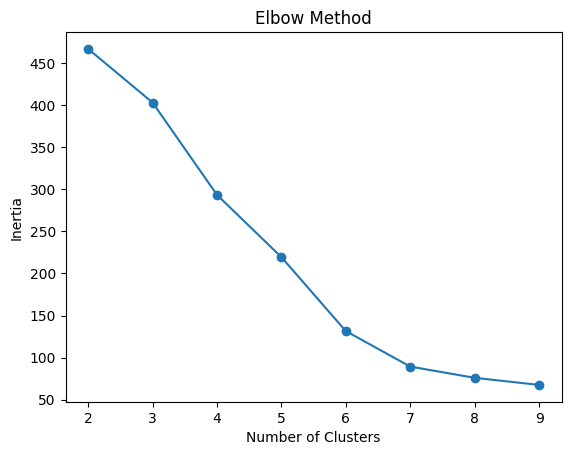

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [10]:
k = 4  # adjust based on elbow

kmeans = KMeans(n_clusters=k, random_state=42)
cluster_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
cluster_df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

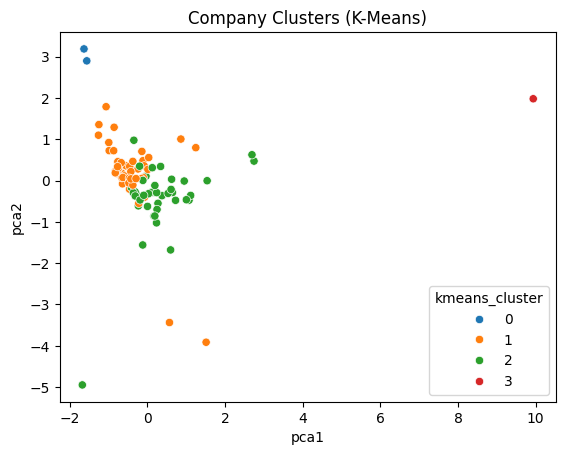

In [12]:
import seaborn as sns

sns.scatterplot(
    data=cluster_df,
    x='pca1',
    y='pca2',
    hue='kmeans_cluster',
    palette='tab10'
)

plt.title("Company Clusters (K-Means)")
plt.show()

In [13]:
cluster_df.groupby('kmeans_cluster')[features].mean()

,net_profit_margin_pct,sales,debt_to_equity,cash_conversion_ratio,dividend_payout_pct,return_on_assets
kmeans_cluster,,,,,,
0,16.234749,17208.562500,0.934010,0.710314,34.291667,1807.520792
1,13.827508,48888.040232,0.480479,3.307853,41.202547,28.873480
2,26.791131,66785.503848,4.159216,0.320313,8.947884,3.854423
3,1.886008,707444.166667,97.583780,8.908773,7.833333,0.314100


In [14]:
pd.crosstab(cluster_df['kmeans_cluster'], cluster_df['sector_name'])

sector_name,Auto,Banking,Cement,Consumer Goods,Consumer Services,Energy,Finance,Healthcare,Holding Company,IT,Industrial,Insurance,Metals,NBFC,Paint,Power,Real Estate,Telecom,Transport
kmeans_cluster,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0
1,8,0,1,6,0,4,1,4,0,5,5,2,0,0,2,5,1,1,2
2,1,9,2,4,1,4,0,2,1,0,2,2,4,7,0,1,1,0,1
3,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
